In [22]:
import requests,json,os,datetime,zipfile
import geopandas as gpd
import pandas as pd
from datetime import datetime, timedelta
from google.colab import files

## Download Data

In [3]:
import pandas as pd
import urllib.parse

# Step 1: Base URL
base_url = "https://www.dallasopendata.com/resource/d7e7-envw.json"

# Step 2: Query for 2024 records (encode it safely)
where = "created_date >= '2024-01-01T00:00:00' AND created_date < '2025-01-01T00:00:00'"
encoded = urllib.parse.quote(where)

# Step 3: Combine into one full URL
full_url = f"{base_url}?$where={encoded}"

# Step 4: Load JSON data
data = pd.read_json(full_url)

# Step 5: Show and save
print(data.head())
data.to_csv("dallas_311_2024.csv", index=False)
print("✅ Saved as dallas_311_2024.csv")



  service_request_number                                   address  \
0            24-00000001         6527 LANGE CIR, DALLAS, TX, 75214   
1            24-00000002  ELM ST & N HOUSTON ST, DALLAS, TX, 75202   
2            24-00000002  ELM ST & N HOUSTON ST, DALLAS, TX, 75202   
3            24-00000005      3818 HAMILTON AVE, DALLAS, TX, 75210   
4            24-00000010          2216 MAIL AVE, DALLAS, TX, 75235   

   city_council_district                                  department  \
0                      9                           Police Department   
1                     14  Transportation and Public Works Department   
2                     14                              Transportation   
3                      7                           Police Department   
4                      2                           Police Department   

                 service_request_type overall_service_request_due_date  \
0                     Fireworks - DPD          2024-01-04T23:59:00.000  

## Inspect Data
## Number of Row

In [4]:
df = pd.read_csv("dallas_311_2024.csv")

In [5]:
row_count = len(df)
print(f"Number of rows: {row_count}")

Number of rows: 1000


### Modify the Column Names

In [7]:
## Keep want colname less 10 char
### {old name: new name}
column_mapping = {
    "service_request_number": "Ser_Num",
    "service_request_type": "Type",
    "created_date": "Date",
    "lat_location": "Lat_Long",
}

In [18]:
def preprocess_data(df):
    """
    Preprocesses the input DataFrame containing 311 data.

    Parameters:
        df (DataFrame): Input DataFrame containing 311 service request data.

    Returns:
        DataFrame: Preprocessed DataFrame with separate latitude and longitude columns.
    """
    import pandas as pd

    # Convert 'created_date' column to datetime format
    df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')

    # Select desired columns
    want_col = ["service_request_number", "service_request_type", "created_date", "lat_location"]
    part_df = df[want_col].copy()

    # Extract latitude and longitude from 'lat_location' column
    # Example format: "(32.83108631962040000,-96.85465316346955000)"
    part_df[['latitude', 'longitude']] = (
        part_df['lat_location']
        .str.replace(r"[()]", "", regex=True)  # remove parentheses
        .str.split(",", expand=True)  # split into two columns
        .astype(float)  # convert strings to numeric
    )

    # Create a formatted date column
    part_df['date'] = part_df['created_date'].dt.strftime("%Y-%m-%d")

    return part_df

processed_df = preprocess_data(df)

# Rename the columns using the column_mapping dictionary
processed_df.rename(columns=column_mapping, inplace=True)
# processed_df.drop_duplicates(subset=['Ser_Num'],inplace=True)  ## Remove redundant records
processed_df.head()

,service_request_number,service_request_type,created_date,lat_location,latitude,longitude,date
0,24-00000001,Fireworks - DPD,2024-01-01 00:00:36,"(32.84207571097978000,-96.74935354626642000)",32.842076,-96.749354,2024-01-01
1,24-00000002,Parking - Report a Violation - TRN,2024-01-01 00:01:27,"(32.77955179297493000,-96.80807323795094000)",32.779552,-96.808073,2024-01-01
2,24-00000002,Parking - Report a Violation - TRN,2024-01-01 00:01:27,"(32.77955179297493000,-96.80807323795094000)",32.779552,-96.808073,2024-01-01
3,24-00000005,Fireworks - DPD,2024-01-01 00:04:32,"(32.77277110318386000,-96.75327545999794000)",32.772771,-96.753275,2024-01-01
4,24-00000010,Fireworks - DPD,2024-01-01 00:10:34,"(32.83108631962040000,-96.85465316346955000)",32.831086,-96.854653,2024-01-01


### Practice in Class

In [20]:
### save the processed_df file as 'dallas_incidents_2024_updated.csv'
processed_df.to_csv("dallas_311_2024_updated.csv", index=False)

In [26]:
# Create GeoDataFrame for the last 28 days
shp_incident = gpd.GeoDataFrame(processed_df, geometry=gpd.points_from_xy(processed_df.longitude,
                                                                    processed_df.latitude,  crs='EPSG:4326'))


Text(86.9788732630412, 0.5, 'Latitude')

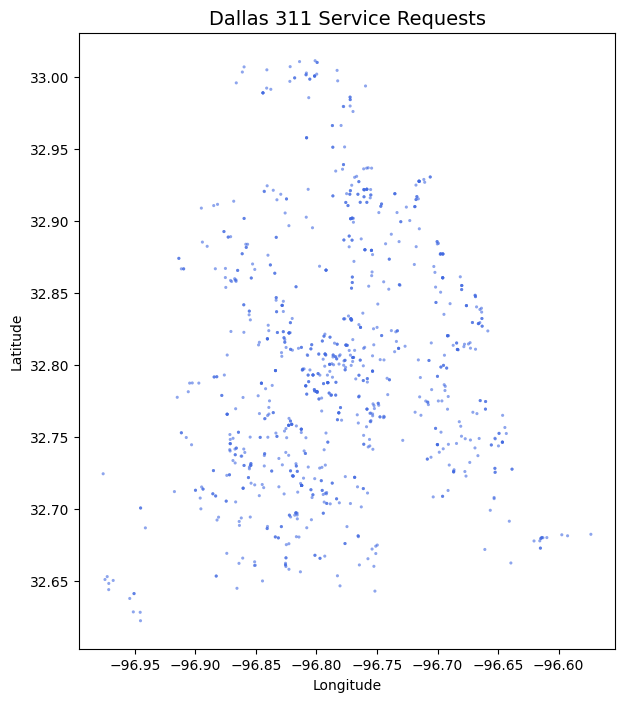

In [27]:
import matplotlib.pyplot as plt

# Plot the shapefile points
fig, ax = plt.subplots(figsize=(8, 8))
shp_incident.plot(ax=ax, color="royalblue", markersize=5, alpha=0.6, edgecolor="none")

# Add title and labels
ax.set_title("Dallas 311 Service Requests", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add grid


In [30]:
shp_incident.to_file('dallas_311')

/tmp/ipython-input-1087493504.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  shp_incident.to_file('dallas_311')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'service_request_number' to 'service_re'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'service_request_type' to 'service__1'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'created_date' to 'created_da'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field created_da create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lat_location' to 'lat_locati'
  ogr_write(


In [31]:
!zip -r dallas_311.zip dallas_311/
from google.colab import files
files.download("dallas_311.zip")


updating: dallas_311/ (stored 0%)
updating: dallas_311/dallas_311.prj (deflated 17%)
updating: dallas_311/dallas_311.shp (deflated 54%)
updating: dallas_311/dallas_311.cpg (stored 0%)
updating: dallas_311/dallas_311.dbf (deflated 92%)
updating: dallas_311/dallas_311.shx (deflated 73%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
!rm -rf /content/dallas_311